## Step 1 — Upload your dataset
Run the cell below, then click **Choose Files** and select `DATASET.zip`.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving DATASETBIG.zip to DATASETBIG.zip


In [2]:
import zipfile, os
zip_path = "DATASETBIG.zip"
extract_path = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
for root, dirs, files_ in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files_[:5]:
            print(f"{indent}  {f}")

dataset/
  WITHOUTMASK/
    simple406.jpg
    simple577.jpg
    simple488.jpg
    simple778.jpg
    simple655.jpg
  WITHFACE/
    simple75.jpg
    simple406.jpg
    simple220.jpg
    simple577.jpg
    simple488.jpg


# Step 2 — Set up paths and check class balance

In [3]:
import os
def _normalize(name):
    return ''.join(ch for ch in name.upper() if ch.isalpha())
data_dir = None
with_mask_name = None
without_mask_name = None
for root, dirs, files_ in os.walk(extract_path):
    norm_map = {_normalize(d): d for d in dirs}
    if 'WITHFACE' in norm_map and 'WITHOUTMASK' in norm_map:
        data_dir = root
        with_mask_name = norm_map['WITHFACE']
        without_mask_name = norm_map['WITHOUTMASK']
        break
if data_dir is None:
    print("Could not auto-detect WITH_MASK / WITHOUT_MASK folders.")
    print("Here is the actual folder structure found in your zip:\n")
    for root, dirs, files_ in os.walk(extract_path):
        level = root.replace(extract_path, '').count(os.sep)
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root) or root}/")
        for d in dirs:
            print(f"{indent}  {d}/")
    raise AssertionError(
        "Could not find WITH_MASK / WITHOUT_MASK folders (even with flexible name "
        "matching) — check the printed structure above and either rename your "
        "folders to WITH_MASK / WITHOUT_MASK, or update this cell to match the "
        "names you actually have."
    )
print("Using data_dir:", data_dir)
print(f"Detected class folders: '{with_mask_name}' and '{without_mask_name}'")
with_mask_count = len(os.listdir(os.path.join(data_dir, with_mask_name)))
without_mask_count = len(os.listdir(os.path.join(data_dir, without_mask_name)))
print(f"WITH_MASK images: {with_mask_count}")
print(f"WITHOUT_MASK images: {without_mask_count}")

Using data_dir: /content/dataset
Detected class folders: 'WITHFACE' and 'WITHOUTMASK'
WITH_MASK images: 689
WITHOUT_MASK images: 537


# Step 3 — Preview some sample images

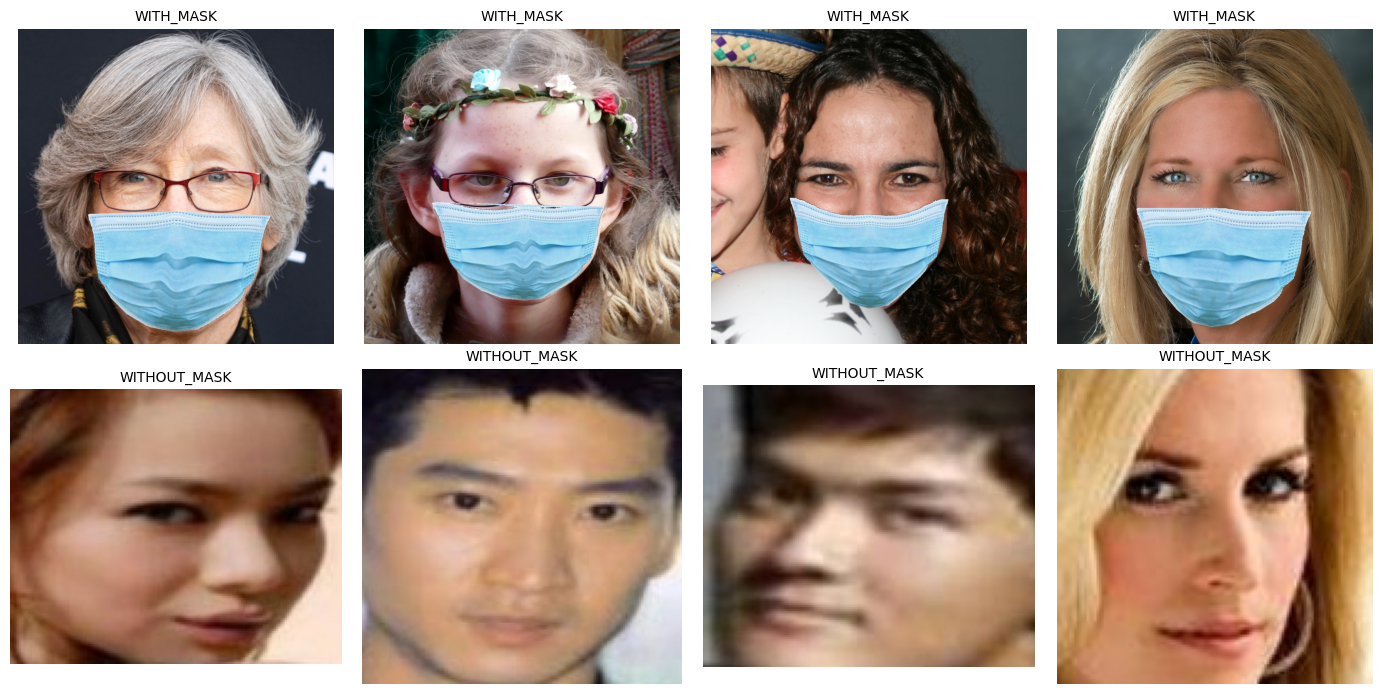

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, (cls, folder_name) in enumerate([('WITH_MASK', with_mask_name), ('WITHOUT_MASK', without_mask_name)]):
    folder = os.path.join(data_dir, folder_name)
    sample_files = os.listdir(folder)[:4]
    for j, fname in enumerate(sample_files):
        img = Image.open(os.path.join(folder, fname))
        axes[i, j].imshow(img)
        axes[i, j].set_title(cls, fontsize=10)
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

# Step 4 — Build data pipelines (with heavy augmentation)

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = 224
BATCH_SIZE = 8
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    classes=[without_mask_name, with_mask_name],
    shuffle=True,
    seed=42
)
val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    classes=[without_mask_name, with_mask_name],
    shuffle=False,
    seed=42
)
print("Class indices:", train_generator.class_indices)

Found 982 images belonging to 2 classes.
Found 244 images belonging to 2 classes.
Class indices: {'WITHOUTMASK': 0, 'WITHFACE': 1}


# Step 5 — Build the model (Transfer Learning: MobileNetV2)

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 6 — Train the model

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]
EPOCHS = 5
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 66s 489ms/step - accuracy: 0.8859 - loss: 0.2868 - val_accuracy: 0.9959 - val_loss: 0.0491 - learning_rate: 1.0000e-04
Epoch 2/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 58s 468ms/step - accuracy: 0.9756 - loss: 0.0875 - val_accuracy: 0.9959 - val_loss: 0.0276 - learning_rate: 1.0000e-04
Epoch 3/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 56s 456ms/step - accuracy: 0.9817 - loss: 0.0572 - val_accuracy: 1.0000 - val_loss: 0.0152 - learning_rate: 1.0000e-04
Epoch 4/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 57s 465ms/step - accuracy: 0.9898 - loss: 0.0494 - val_accuracy: 1.0000 - val_loss: 0.0087 - learning_rate: 1.0000e-04
Epoch 5/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 57s 463ms/step - accuracy: 0.9888 - loss: 0.0320 - val_accuracy: 1.0000 - val_loss: 0.0094 - learning_rate: 1.0000e-04


# Step 7 — Plot training curves

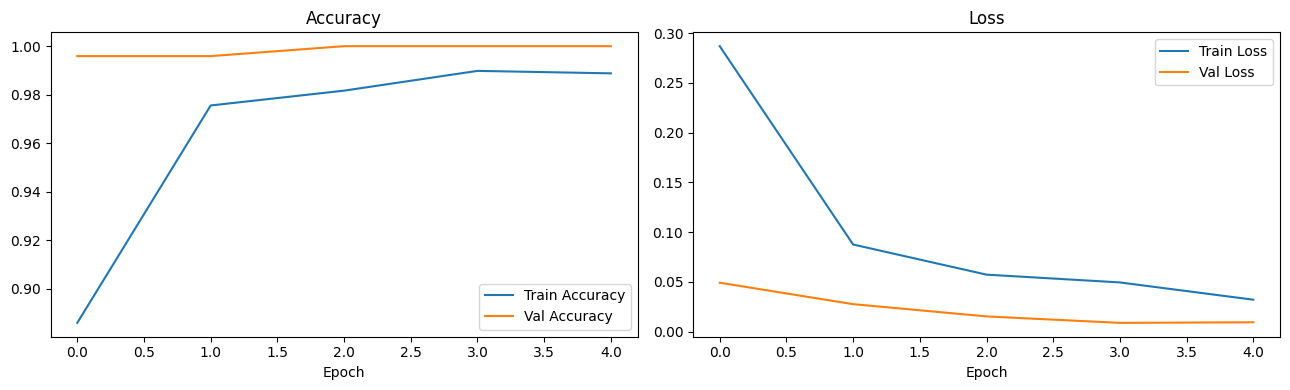

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

# Step 8 — Evaluate the model

In [9]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 344ms/step - accuracy: 1.0000 - loss: 0.0102
Validation Accuracy: 100.00%
Validation Loss: 0.0102


31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 382ms/step
              precision    recall  f1-score   support

WITHOUT_MASK       1.00      0.99      1.00       107
   WITH_MASK       0.99      1.00      1.00       137

    accuracy                           1.00       244
   macro avg       1.00      1.00      1.00       244
weighted avg       1.00      1.00      1.00       244



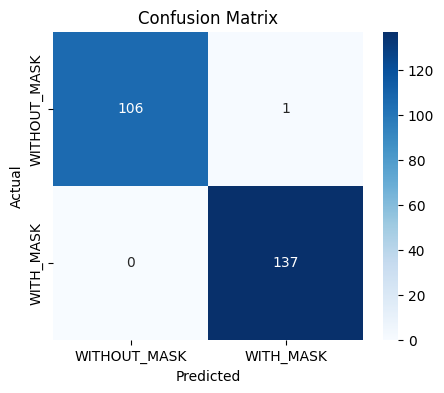

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
val_generator.reset()
preds = model.predict(val_generator)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = val_generator.classes
print(classification_report(true_labels, pred_labels, target_names=['WITHOUT_MASK', 'WITH_MASK']))
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['WITHOUT_MASK', 'WITH_MASK'],
            yticklabels=['WITHOUT_MASK', 'WITH_MASK'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 9 — Save the trained model

In [11]:
model.save('face_mask_detector.h5')
print("Model saved as face_mask_detector.h5")
from google.colab import files
files.download('face_mask_detector.h5')

Model saved as face_mask_detector.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 10 — Predict on a new image (with face detection)

Saving simple593.jpg to simple593 (1).jpg
Raw prediction value: 0.0022


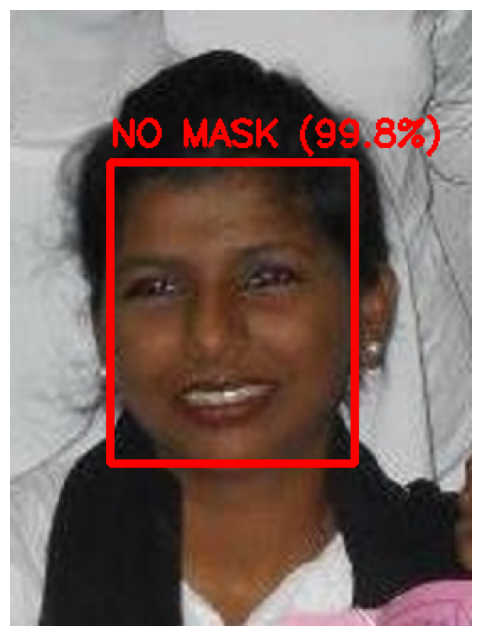

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request
MASK_IS_ZERO = False
IMG_SIZE = 224
PROTOTXT_PATH = "deploy.prototxt"
MODEL_PATH = "res10_300x300_ssd_iter_140000.caffemodel"
PROTOTXT_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
MODEL_URL = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"
def ensure_face_detector_files():
    if not os.path.exists(PROTOTXT_PATH):
        urllib.request.urlretrieve(PROTOTXT_URL, PROTOTXT_PATH)
    if not os.path.exists(MODEL_PATH):
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
ensure_face_detector_files()
face_net = cv2.dnn.readNetFromCaffe(PROTOTXT_PATH, MODEL_PATH)
def detect_faces_dnn(img, conf_threshold=0.5):
    h, w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(img, 1.0, (300, 300), (104.0, 177.0, 123.0))
    face_net.setInput(blob)
    detections = face_net.forward()
    boxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype(int)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            boxes.append((x1, y1, x2 - x1, y2 - y1))
    return boxes
def predict_mask(image_path, model, img_size=IMG_SIZE, debug=True):
    img = cv2.imread(image_path)
    if img is None:
        print("Could not read image:", image_path)
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detect_faces_dnn(img)
    if len(faces) == 0:
        print("No face detected — running prediction on a center crop instead.")
        h, w = img.shape[:2]
        side = min(h, w)
        cx, cy = w // 2, h // 2
        x = max(0, cx - side // 2)
        y = max(0, cy - side // 2)
        faces = [(x, y, side, side)]
    for (x, y, w, h) in faces:
        face = img_rgb[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (img_size, img_size))
        face_array = face_resized.astype(np.float32) / 255.0
        face_array = np.expand_dims(face_array, axis=0)
        pred = model.predict(face_array, verbose=0)[0][0]
        if debug:
            print(f"Raw prediction value: {pred:.4f}")
        if MASK_IS_ZERO:
            is_mask = pred < 0.5
            confidence = (1 - pred) if is_mask else pred
        else:
            is_mask = pred > 0.5
            confidence = pred if is_mask else (1 - pred)

        label = "MASK" if is_mask else "NO MASK"
        color = (0, 255, 0) if is_mask else (255, 0, 0)

        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
        cv2.putText(img_rgb, f"{label} ({confidence*100:.1f}%)", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
from google.colab import files
uploaded_test = files.upload()
test_image_path = list(uploaded_test.keys())[0]
predict_mask(test_image_path, model)